`Machine Learning Clasificación y Regresión | Analía Elizabeth Gomory | Salta - 4400 - Argentina | 2025`

**by Analía Elizabeth Gomory**

* ae.gomory@gmail.com

* http://www.linkedin.com/in/elizabeth-gomory-9240b1217

* https://ae-gomory.itch.io

* https://github.com/ElizabethGomory

* https://www.credly.com/users/analia-gomory

* https://orcid.org/0009-0003-0498-7658

# Formulación del problema

Para el ejercicio debemos cargar el Dataset que viene en `https://www.kaggle.com/`(https://www.kaggle.com/fedesoriano/stroke-prediction-dataset). El detalle es el siguiente:

Según la Organización Mundial de la Salud (OMS), el accidente cerebrovascular es la segunda causa principal de muerte a nivel mundial, responsable de aproximadamente el 11% del total de muertes.
Este conjunto de datos se utiliza para predecir si es probable que un paciente sufra un accidente cerebrovascular en función de los parámetros de entrada como el sexo, la edad, diversas enfermedades y el tabaquismo. Cada fila de los datos proporciona información relevante sobre el paciente.

Información de atributos

1) id: identificador único

2) genero: "Masculino", "Femenino" u "Otro"

3) age: edad del paciente

4) hypertension: 0 si el paciente no tiene hipertensión, 1 si el paciente tiene hipertensión

5) heart_disease: 0 si el paciente no tiene ninguna enfermedad cardíaca, 1 si el paciente tiene una enfermedad cardíaca

6) ever_married: "No" o "Sí"

7) work_type: "niños", "Govt_jov", "Nunca_trabajado", "Privado" o "Trabajador por cuenta propia"

8) Residence_type: "Rural" o "Urban"

9) avg_glucose_level: nivel medio de glucosa en sangre

10) bmi: índice de masa corporal

11) smoking_status: "anteriormente fumador", "nunca fumador", "fuma" o "Desconocido" *

12) accidente cerebrovascular: 1 si el paciente tuvo un accidente cerebrovascular o 0 si no

* Nota: "Desconocido" en smoking_status significa que la información no está disponible para este paciente.

In [ ]:
# Definimos componentes a utilizar en la primera parte
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
#df = pd.read_csv('C:/xxxx/machine learning/healthcare-dataset-stroke-data.csv') # Si caargamos directamente de nuestro PC si estuviesemos trabajando con anaconda local

# Recopilar, etiquetar y evaluar los datos

#### Alternativa de cargar el archivo desde nuestro equipo local

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

df = pd.read_csv('healthcare-dataset-stroke-data.csv')

df.head(5)

FileNotFoundError: ignored

#### Alternativa de montar nuestro Drive y cargar el archivo desde el drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/healthcare-dataset-stroke-data.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Retornar los últimas n filas del data set
df.tail(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [ ]:
#Obtener n cantidad de filas aleatorias del dataframe
df.sample(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
2939,52367,Male,46.0,0,0,Yes,Private,Urban,58.42,24.7,formerly smoked,0
2899,33976,Male,55.0,0,0,Yes,Private,Urban,68.79,27.0,never smoked,0
2437,19088,Male,8.0,0,0,No,children,Urban,105.63,19.2,Unknown,0
4411,13237,Male,57.0,0,1,Yes,Self-employed,Urban,112.37,28.4,never smoked,0
1955,71182,Female,61.0,1,0,Yes,Govt_job,Urban,153.38,38.8,never smoked,0


In [ ]:
#Determinar el tamaño de la matriz de datos
df.shape

(5110, 12)

In [ ]:
#Cuenta los valores únicos del dataframe
df.value_counts()

id     gender  age   hypertension  heart_disease  ever_married  work_type      Residence_type  avg_glucose_level  bmi   smoking_status   stroke
77     Female  13.0  0             0              No            children       Rural           85.81              18.6  Unknown          0         1
49605  Male    63.0  0             0              Yes           Private        Urban           74.39              31.0  formerly smoked  0         1
49661  Male    53.0  0             0              Yes           Govt_job       Urban           85.17              29.2  never smoked     0         1
49646  Male    72.0  0             1              Yes           Self-employed  Rural           113.63             26.5  Unknown          0         1
49645  Male    58.0  0             0              No            Private        Rural           76.22              22.2  formerly smoked  0         1
                                                                                                               

In [ ]:
#Cuenta valores por columna
df.count()

id                   5110
gender               5110
age                  5110
hypertension         5110
heart_disease        5110
ever_married         5110
work_type            5110
Residence_type       5110
avg_glucose_level    5110
bmi                  4909
smoking_status       5110
stroke               5110
dtype: int64

In [ ]:
#Indica las medidas estadísticas de acuerdo a cada columna continua
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [ ]:
#Entrega información sobre los tipo de datos del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


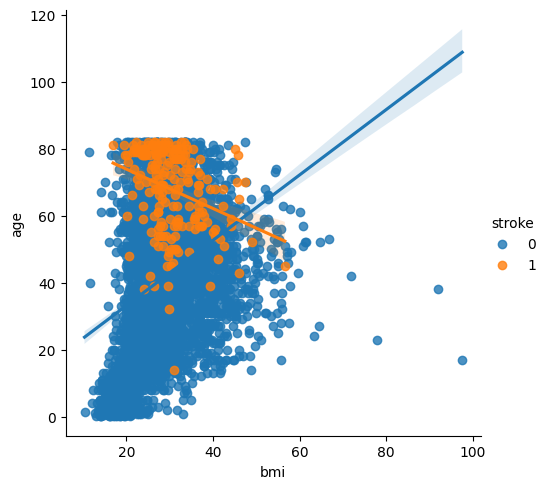

In [ ]:
#Podemos graficar la relación entre BMI y edad de para el peligro de accidente cardiovascular
from seaborn import lmplot
lmplot(x="bmi", y="age", hue="stroke", data=df)

<Axes: xlabel='stroke', ylabel='age'>

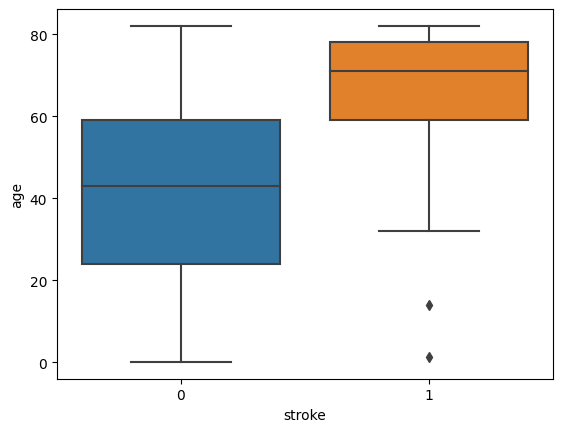

In [ ]:
#Graficamos en el boxplot entre que edades se concentran los accidentes cardivasculares
from seaborn import boxplot
boxplot(x="stroke", y="age", data=df)

0         Axes(0.1,0.15;0.363636x0.75)
1    Axes(0.536364,0.15;0.363636x0.75)
dtype: object

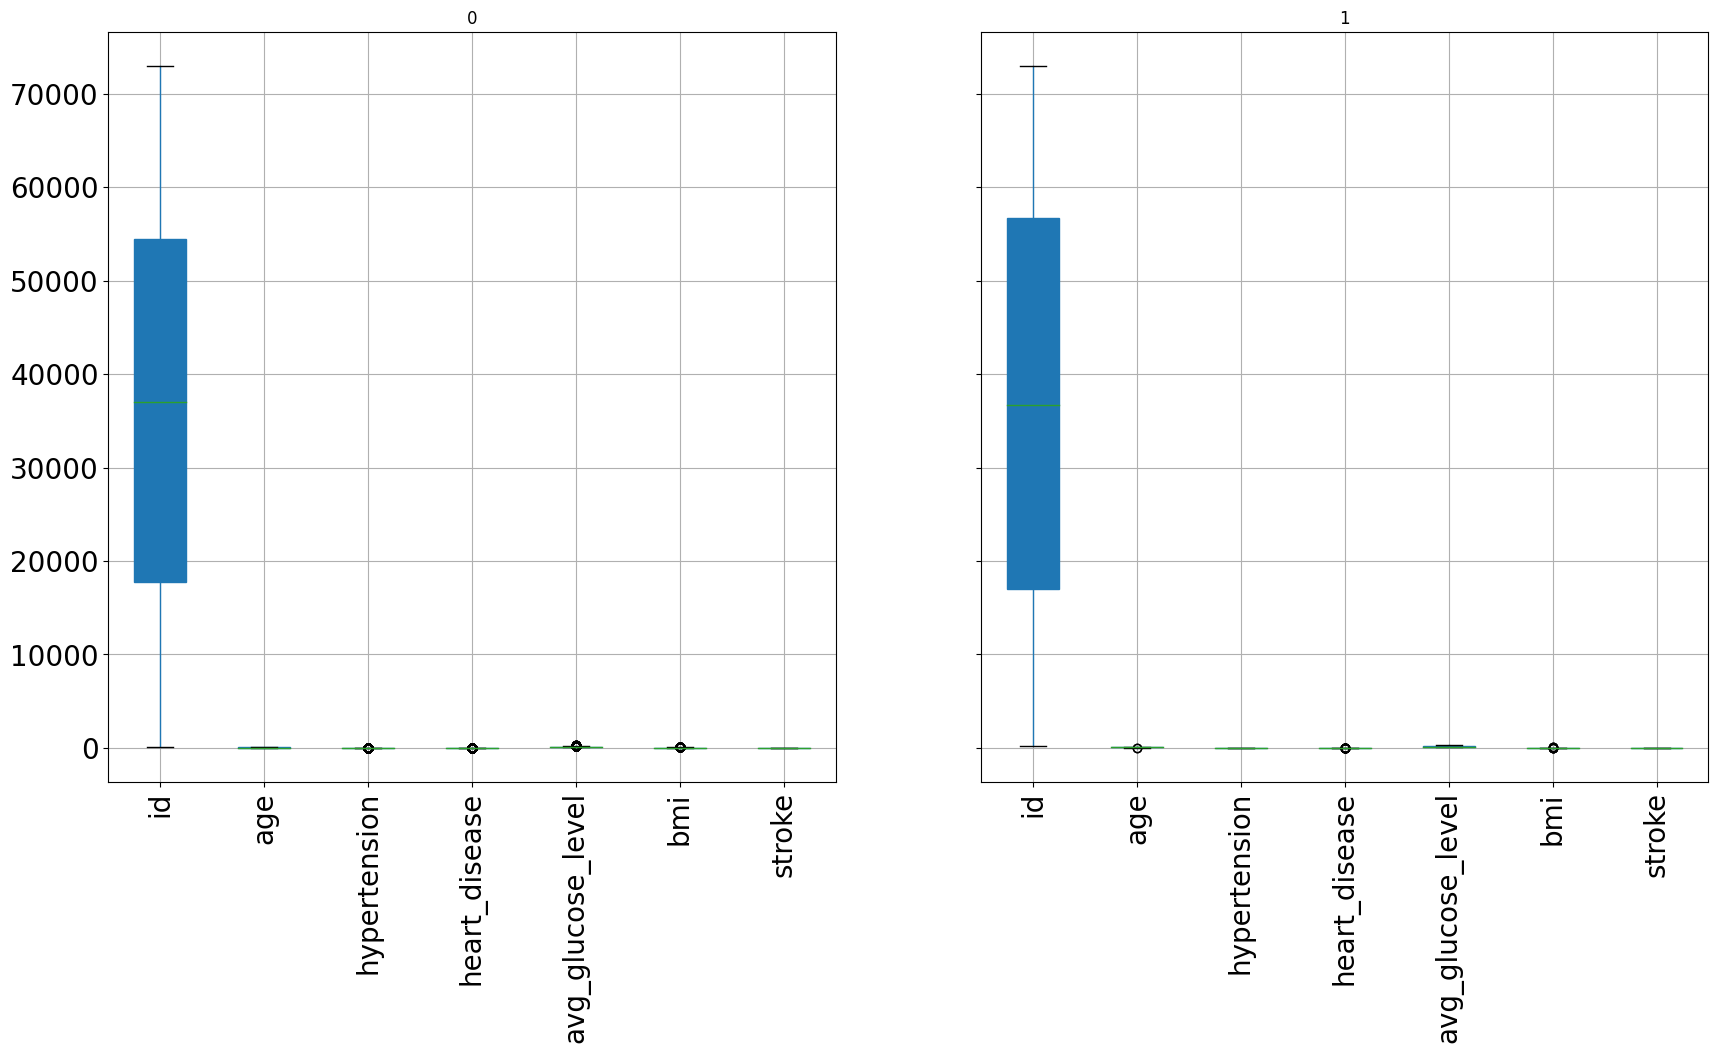

In [ ]:
#Graficamos en el boxplot entre que edades se concentran los accidentes cardivasculares
df.groupby('stroke').boxplot(fontsize=20,rot=90,figsize=(20,10),patch_artist=True)

<Axes: xlabel='hypertension', ylabel='age'>

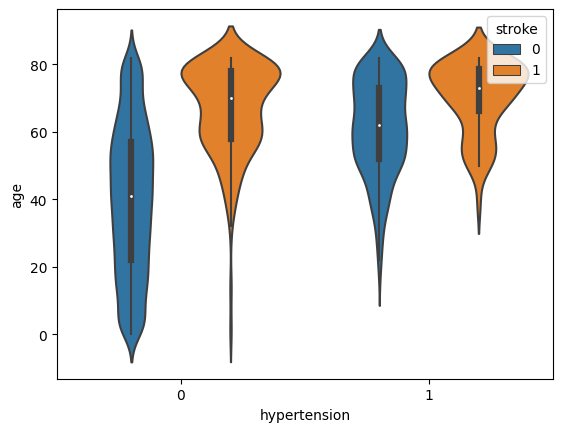

In [ ]:
#También podemos graficar en un tipo violinplot la relación entre la hipertensión y la edad
#con respecto a los accidentes cardiovasculares
from seaborn import violinplot
violinplot(x="hypertension", y="age", hue="stroke", data=df)

<Axes: xlabel='avg_glucose_level', ylabel='Density'>

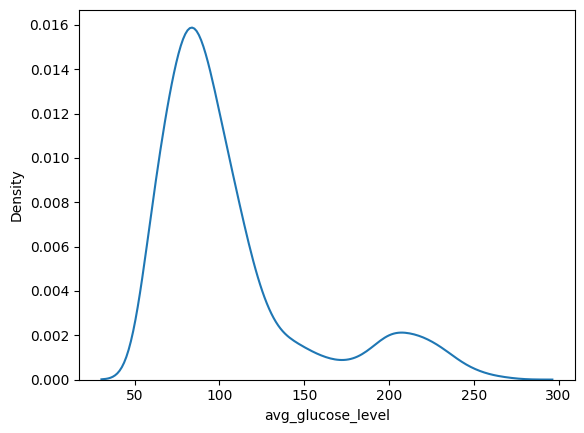

In [ ]:
#Utilizamos un gráfico de estimación de distribución de kernel que representa la función de densidad de probabilidad
#de las variables de datos continuas. En partcular podemos ver donde se concentran los niveles de glocosa
from seaborn import kdeplot
kdeplot(df.avg_glucose_level)

<ipython-input-84-a9cbe9ee19af>:4: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='age', ylabel='Density'>

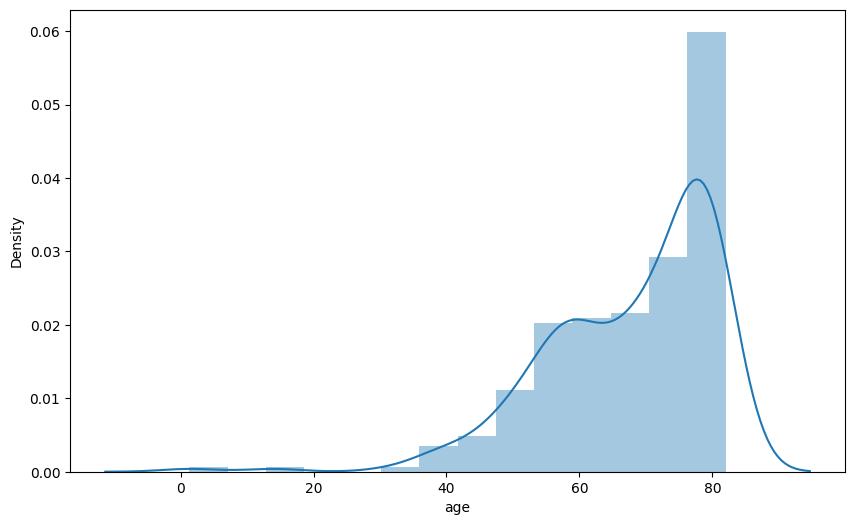

In [ ]:
# Ataques cardiovasculares con respecto a la edad del paciente
plt.figure(figsize = (10,6))
stroke = df[df['stroke']==1]
sns.distplot(stroke.age)

# Diseño de características

#### 1.- Limpieza de datos

In [ ]:
#Podemos identificar duplicados
print("Identificar duplicados:")
print(df.duplicated())
#Borrar los duplicados
df = df.drop_duplicates()

Identificar duplicados:
0       False
1       False
2       False
3       False
4       False
        ...  
5105    False
5106    False
5107    False
5108    False
5109    False
Length: 5110, dtype: bool


In [ ]:
#Si se desea se puede identificar duplicados que se han guardado con el nombre de una columna diferente,
#por ejemplo buscamos que se hayn guardado con distinto género
df.duplicated(df.columns[~df.columns.isin(['gender'])])

#Eliminamos el duplicado
#importante método es keep mediante la cual se puede indicas si se conserva la primera (firest) o ultima ocurrencia (last)
#por defecto es la primera
df = df.drop_duplicates(df.columns[~df.columns.isin(['id'])],
                        keep='first')
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [ ]:

#Revisamos los nulos de las columnas
print(df.isnull().sum())
print(df.shape[0])
print("Porcentaje de nulos")
print((df.bmi.isnull().sum()*100)/df.shape[0])
print(df.groupby(["stroke"])["stroke"].count())

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64
5110
Porcentaje de nulos
3.9334637964774952
stroke
0    4861
1     249
Name: stroke, dtype: int64


In [ ]:
#Comprobamos si las variables categoricas no tienen NaN
df.info()
obj_df = df.select_dtypes(include=['object'])
print(obj_df.isna().sum())
#obj_df.head(5)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 519.0+ KB
gender            0
ever_married      0
work_type         0
Residence_type    0
smoking_status    0
dtype: int64


In [ ]:
#Cantidad y porcentaje de valores únicos
count = df.nunique()
print(count)
print((count*100)/df.shape[0])

id                   5110
gender                  3
age                   104
hypertension            2
heart_disease           2
ever_married            2
work_type               5
Residence_type          2
avg_glucose_level    3979
bmi                   418
smoking_status          4
stroke                  2
dtype: int64
id                   100.000000
gender                 0.058708
age                    2.035225
hypertension           0.039139
heart_disease          0.039139
ever_married           0.039139
work_type              0.097847
Residence_type         0.039139
avg_glucose_level     77.866928
bmi                    8.180039
smoking_status         0.078278
stroke                 0.039139
dtype: float64


In [ ]:
#Eliminar columna no relevante
df= df.drop(['id'],axis=1)

#### 2.- Tratamiento de valores ordinales

In [ ]:
all_columns = list(df.columns)
categorical_data_cols  = [column for column in all_columns if len(df[column].unique())<=5]
continuous_data_cols  = [column for column in all_columns if column not in categorical_data_cols]
print(f"Columnas Data continua: {', '.join(continuous_data_cols)}")
print(f"Columnas Data categórica: {', '.join(categorical_data_cols)}")

Columnas Data continua: age, avg_glucose_level, bmi
Columnas Data categórica: gender, hypertension, heart_disease, ever_married, work_type, Residence_type, smoking_status, stroke


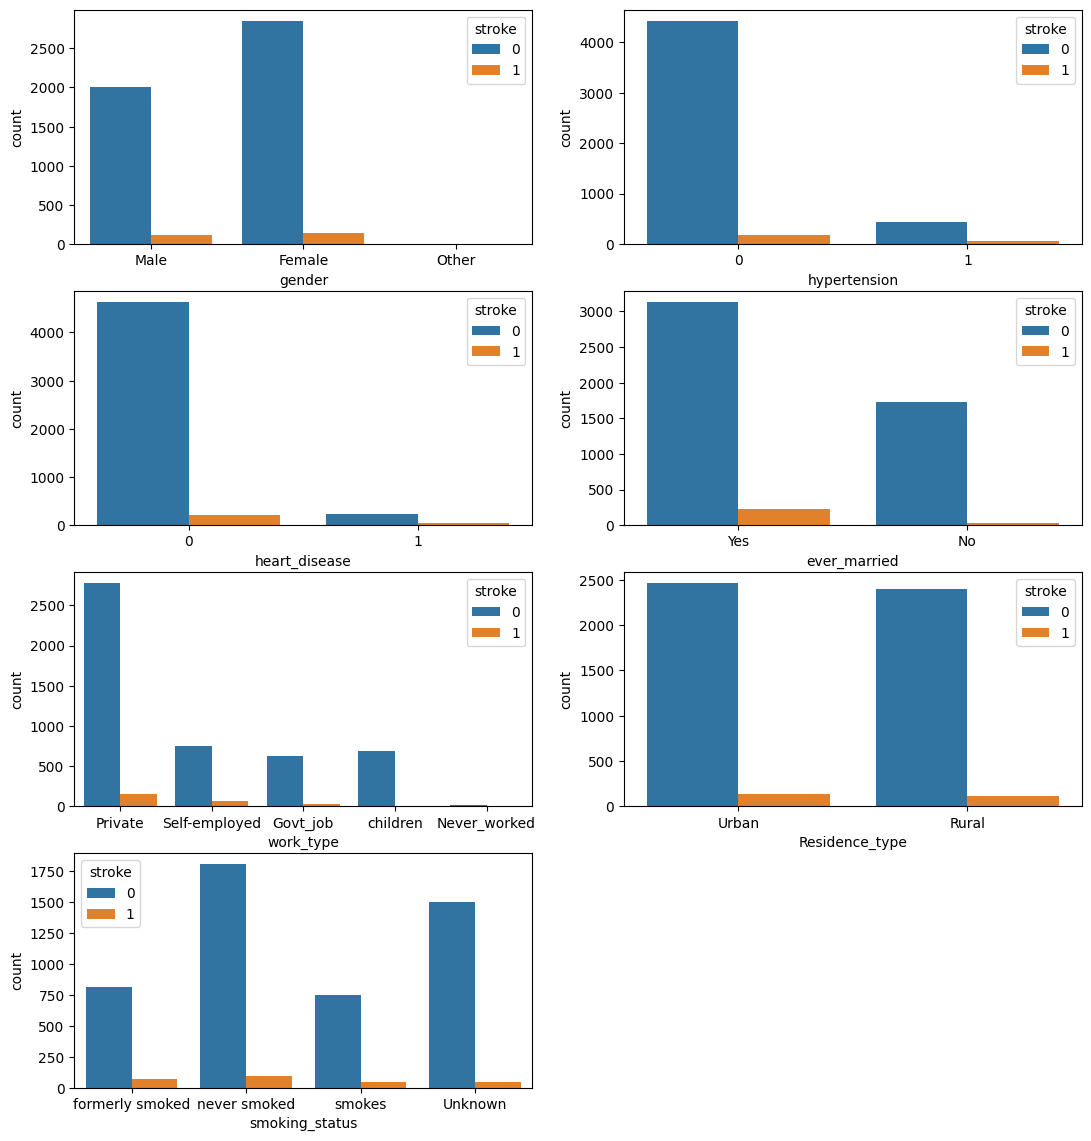

In [ ]:
# Graficamos las variables con respecto al label
plt.figure(figsize = (13,14))
i = 1
for column in categorical_data_cols[:-1]:
    plt.subplot(4, 2, i)
    sns.countplot(x = df[column], hue = df["stroke"])
    i+=1
plt.show()

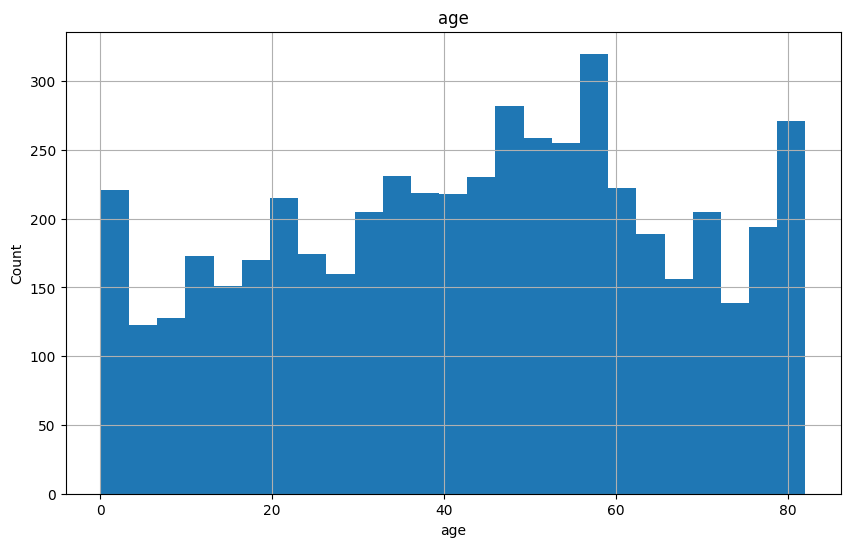

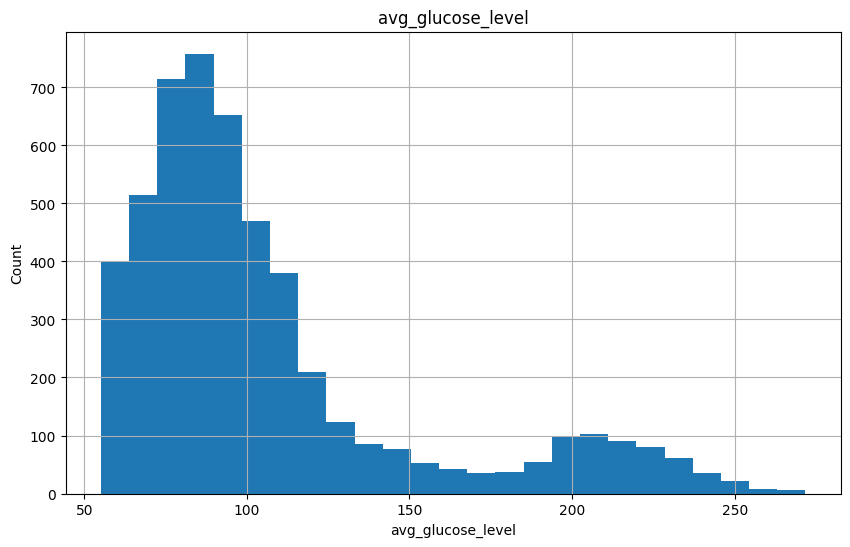

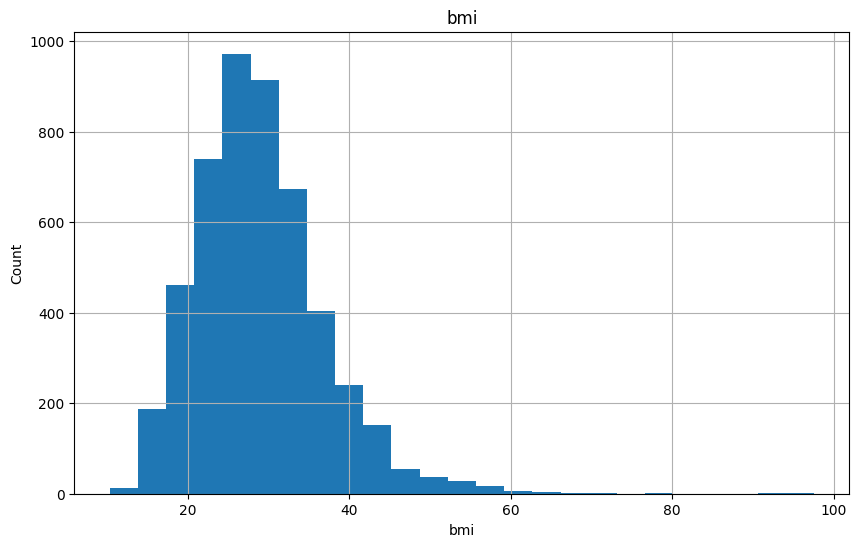

In [ ]:
# Histogramas
for feature in continuous_data_cols:
    plt.figure(figsize = (10,6))
    data=df.copy()
    data[feature].hist(bins=25)
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.title(feature)
    plt.show()

In [ ]:
# Cambiar los datos categóricos a data numérica
from sklearn.preprocessing import OrdinalEncoder

df["ever_married"] = df["ever_married"].astype(str)
ord_enc = OrdinalEncoder()
df[["gender","ever_married","work_type","Residence_type","smoking_status"]]= ord_enc.fit_transform(df[["gender","ever_married","work_type","Residence_type","smoking_status"]])
df.head(5)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1.0,67.0,0,1,1.0,2.0,1.0,228.69,36.6,1.0,1
1,0.0,61.0,0,0,1.0,3.0,0.0,202.21,NaN,2.0,1
2,1.0,80.0,0,1,1.0,2.0,0.0,105.92,32.5,2.0,1
3,0.0,49.0,0,0,1.0,2.0,1.0,171.23,34.4,3.0,1
4,0.0,79.0,1,0,1.0,3.0,0.0,174.12,24.0,2.0,1


In [ ]:
# Revisamos las correlaciones ya con todos los datos transformados a numércios: Matriz de Correlación
df.corr().style.background_gradient(cmap ='coolwarm')

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
gender,1.000000,-0.028202,0.020994,0.085447,-0.031005,0.056422,-0.006738,0.055180,-0.026678,-0.062581,0.008929
age,-0.028202,1.000000,0.276398,0.263796,0.679125,-0.361642,0.014180,0.238171,0.333398,0.265199,0.245257
hypertension,0.020994,0.276398,1.000000,0.108306,0.164243,-0.051761,-0.007913,0.174474,0.167811,0.111038,0.127904
heart_disease,0.085447,0.263796,0.108306,1.000000,0.114644,-0.028023,0.003092,0.161857,0.041357,0.048460,0.134914
ever_married,-0.031005,0.679125,0.164243,0.114644,1.000000,-0.352722,0.006261,0.155068,0.341695,0.259647,0.108340
work_type,0.056422,-0.361642,-0.051761,-0.028023,-0.352722,1.000000,-0.007316,-0.050513,-0.304876,-0.305927,-0.032316
Residence_type,-0.006738,0.014180,-0.007913,0.003092,0.006261,-0.007316,1.000000,-0.004946,-0.000122,0.008237,0.015458
avg_glucose_level,0.055180,0.238171,0.174474,0.161857,0.155068,-0.050513,-0.004946,1.000000,0.175502,0.063437,0.131945
bmi,-0.026678,0.333398,0.167811,0.041357,0.341695,-0.304876,-0.000122,0.175502,1.000000,0.224473,0.042374
smoking_status,-0.062581,0.265199,0.111038,0.048460,0.259647,-0.305927,0.008237,0.063437,0.224473,1.000000,0.028123


In [ ]:
#Volvemos a revisar y eliminar nulos y duplicados (si los hay) dado que hemos imputado valores numércios a todas las columnas para tener seguridad
df.groupby(df.ever_married.tolist()).size().reset_index().rename(columns={0:'count'})
df = df.drop_duplicates()
print(df.count())
df2 = df.dropna()
print(df2.count())


gender               5110
age                  5110
hypertension         5110
heart_disease        5110
ever_married         5110
work_type            5110
Residence_type       5110
avg_glucose_level    5110
bmi                  4909
smoking_status       5110
stroke               5110
dtype: int64
gender               4909
age                  4909
hypertension         4909
heart_disease        4909
ever_married         4909
work_type            4909
Residence_type       4909
avg_glucose_level    4909
bmi                  4909
smoking_status       4909
stroke               4909
dtype: int64


In [ ]:
# Para seguridad se grafica nuevamente la correlación de manera que se pueda visulizar las relaziones finales que utilizaremos
df2.corr().style.background_gradient(cmap ='coolwarm')

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
gender,1.000000,-0.030738,0.021578,0.082712,-0.037237,0.058560,-0.005014,0.053664,-0.026678,-0.060004,0.006757
age,-0.030738,1.000000,0.274425,0.257123,0.680782,-0.366987,0.010948,0.235838,0.333398,0.275515,0.232331
hypertension,0.021578,0.274425,1.000000,0.115991,0.162406,-0.052750,-0.001074,0.180543,0.167811,0.110808,0.142515
heart_disease,0.082712,0.257123,0.115991,1.000000,0.111245,-0.030373,-0.002362,0.154525,0.041357,0.055236,0.137938
ever_married,-0.037237,0.680782,0.162406,0.111245,1.000000,-0.357946,0.004989,0.151377,0.341695,0.264642,0.105089
work_type,0.058560,-0.366987,-0.052750,-0.030373,-0.357946,1.000000,-0.005422,-0.050581,-0.304876,-0.310911,-0.033756
Residence_type,-0.005014,0.010948,-0.001074,-0.002362,0.004989,-0.005422,1.000000,-0.007617,-0.000122,0.013810,0.006031
avg_glucose_level,0.053664,0.235838,0.180543,0.154525,0.151377,-0.050581,-0.007617,1.000000,0.175502,0.066335,0.138936
bmi,-0.026678,0.333398,0.167811,0.041357,0.341695,-0.304876,-0.000122,0.175502,1.000000,0.224473,0.042374
smoking_status,-0.060004,0.275515,0.110808,0.055236,0.264642,-0.310911,0.013810,0.066335,0.224473,1.000000,0.051558


#### 3.- Tratamiento de valores atípicos (outliers)

Como no tenemos muchos datos para el ejercicio no realizaremos un tratamiento de valores atípicos, pero podemos encontrar algunos como se muestra

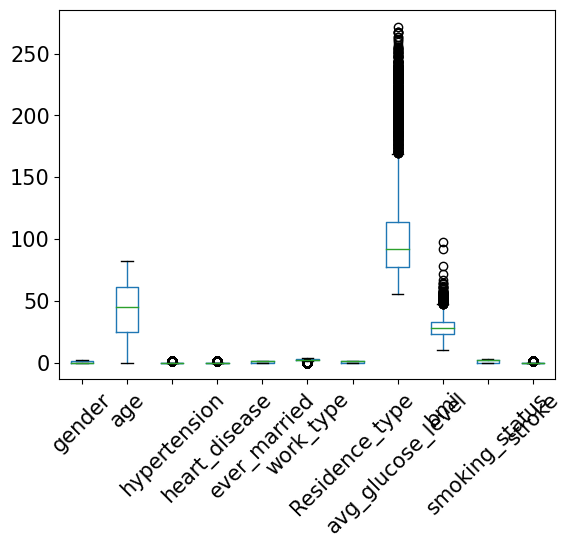

In [ ]:
# Boxplot para validar outliers
df.boxplot(grid=False, rot=45, fontsize=15)
import plotly.express as px
fig = px.box(df, y='bmi')
fig.show()

In [ ]:
# Cálulo de los límites para los outliers
#bajo_ouliers < Q1 - 1.5 * IRQ
#Alto_outliers > Q3 - 1.5 * IRQ
#Donde IQR (Rango intercuartíco) se define como:
#IRQ = Q3 - Q1 y Q1 es el primer cuartil (25%) y Q3 el tercer cuartil (75%)

Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

In [ ]:
upper_array = np.where(df['bmi']>=upper)[0]
lower_array = np.where(df['bmi']<=lower)[0]
lower_array

array([], dtype=int64)

In [ ]:
# Para realizar la operación pero no la consideramos mas adelante en el ejercicio, copiaremos el dataframe para eliminar los outliers y graficar.
df3 = df.copy()
df3.drop(index=upper_array, inplace=True)
df3.drop(index=lower_array, inplace=True)

In [ ]:
fig = px.box(df3, y='bmi')
fig.show()

#### Imputamos valores a bmi, debido a que tiene valores nulos pero pero es una variable interesante. Para calcular los valores faltantes realizaremos un modelo de regresion que aprenderá de las siguientes 3 columnas para obtener el BMI: "age","work_type","smoking_status"]

In [ ]:
# Imprimimos el dataframe y vemos que BMI cuenta con varios nulos
print(df2.count())

gender               4909
age                  4909
hypertension         4909
heart_disease        4909
ever_married         4909
work_type            4909
Residence_type       4909
avg_glucose_level    4909
bmi                  4909
smoking_status       4909
stroke               4909
dtype: int64


In [ ]:
# Creamos el set de características X_ant y el ser de target Y_ant
Y_ant = df2["bmi"]
X_ant = df2[["age","work_type","smoking_status"]]
print(Y_ant.iloc[1])

32.5


In [ ]:
# Se escalan los valores (z = (x - media) / desviación estándar)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_ant)
X_scaled[1]

array([ 1.64656262, -0.15569667,  0.58523176])

#### Se entrena con un estimador de regresión (RandomForestRegressor) para obtener la mejor combinación de hiperparámetros

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

model = RandomForestRegressor()

params = {"n_estimators": [100],
          "min_samples_split": [2,3,4],
          "max_leaf_nodes": [5,8,10,15]}

grid = GridSearchCV(estimator=model, param_grid=params,cv=5)
grid.fit(X_scaled, Y_ant)

print(grid.best_score_)
print(grid.best_params_)

0.24154973674839794
{'max_leaf_nodes': 5, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
# Ya obtenido la mejor combinación de hiperparámetros, dividimos el set en entrenamiento y testing
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X_scaled,Y_ant,test_size=0.3, shuffle=True)

#### Evaluamos el modelo y obtenemos estadísticos que nos indicará si los resultados nor sirven para completar el error. estos son: mean squared error, Mean absolute error y R² score

Los detalles de cada estadistico lo podemos revisar en https://scikit-learn.org/stable/modules/model_evaluation.html

In [ ]:
modelf = RandomForestRegressor(**grid.best_params_)
modelf.fit(Xtrain, Ytrain)
Yhatt = modelf.predict(Xtrain)

mse = mean_squared_error(Ytrain, Yhatt)
mae = mean_absolute_error(Ytrain, Yhatt)
R2 = r2_score(Ytrain, Yhatt)

print("MSE train: ",mse)
print("MAE train: ",mae)
print("R^2 train: ",R2)

Yhat = modelf.predict(Xtest)
mse2 = mean_squared_error(Ytest, Yhat)
mae2 = mean_absolute_error(Ytest, Yhat)
R2_2 = r2_score(Ytest, Yhat)

print("MSE test: ",mse2)
print("MAE test: ",mae2)
print("R^2 test: ",R2_2)

MSE train:  44.79776721342133
MAE train:  4.962583917880344
R^2 train:  0.24813818014224254
MSE test:  50.33171295111988
MAE test:  5.1404468313635405
R^2 test:  0.24355586763317116


In [ ]:
# Predecimos con 1 dato del set de test y vemos que sucede
Yhatt1 = modelf.predict(Xtest[20].reshape(1,Xtest.shape[1]))
print(Yhatt1)
print(Ytest.mean())
print(Ytest.std())
print(Yhat.mean())
print(Yhat.std())
print(Ytest.iloc[20])

[19.30585744]
28.99551934826884
8.159807150675087
28.76184005964494
3.956645641165479
18.7


In [ ]:
# Reemplazamos el dato del BMI con las predicciones obtenidas
for ll in range(0, df.age.count()-1):
    if df["bmi"].isnull()[ll]:
        df["bmi"][ll] = modelf.predict(df[["age","work_type","smoking_status"]].values[ll].reshape(1, Xtest.shape[1]))

<ipython-input-110-7f8863363f91>:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-110-7f8863363f91>:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-110-7f8863363f91>:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-110-7f8863363f91>:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/

In [ ]:
# Verificamos si continúan los nulos para el bmi, es decir, nos aseguramos que se hayan imputado todos los valores
print(df.isnull().sum())

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


#### 4.- Selección de características

stroke: la eliminamos porque es el target, es decir, es el dato a donde debemos llegar

ever_married: Lo eliminamos debido a que no nos aporta mucha información.
Id: ya lo habíamos eliminado en un incio dado que era un número único que nos aportaba al aprendizaje

In [ ]:
Y = df["stroke"]
X = df.drop(["stroke","ever_married"],axis=1)

#### 5.- Normalizar valores de características

In [ ]:
# Se escalan los valores (z = (x - media) / desviación estándar)
scaler = StandardScaler()
X_scaled_F = scaler.fit_transform(X)

# Entrenamiento y selección de modelo

Comenzamos a definir los componentes con lo que vamos a realizar y comparar el entrenamiento

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import itertools

#### Definimos una función para presentar y graficar la matriz de confusión

In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print('Matriz de confusión Normalizada')
    else:
        print('Matriz de confusión sin normalizar')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [ ]:
# Seleccionar el set de entrenamiento y de test
XtrainF, XtestF, YtrainF, YtestF = train_test_split(X_scaled_F,Y, test_size=0.25, shuffle=True)

# 1.- Cross Validation

_¿Tuvimos suerte? Es decir, si hubiésemos elegido otra partición train/test, ¿obtendríamos resultados diferentes?_

Cross-validation nos ayuda a disminuir el efecto del azar (pregunta 1). Por ejemplo, observa qué pasa si cambiamos la semilla aleatoria:

Para disminuir el efecto, _cross-validation_ particiona los datos en $k$ partes iguales, entrena con $k-1$ partes, evalúa en la $k$-ésima, guarda el resultado, y vuelve a repetir el proceso con otras $k-1$ partes hasta haber recorrido todas las partes. Este proceso se llama $k$-fold cross-validation.

Observa que esto implica que el clasificador se entrenará $k$ veces, lo cual puede ser costoso dependiendo del clasificador y de la cantidad de datos.

![](https://upload.wikimedia.org/wikipedia/commons/1/1c/K-fold_cross_validation_EN.jpg)

Se define el cross-validation stratificado con 8 saltos para mezclar los datos  (parámetro **skf** que se aplicará a todos los modelos). Se define estratificado dado que existen mayor cantidad de personas sin accdidentes cardiovasculares lo que hace al set de datos desbalanceado.
El parámetro **skf** se aplica a todos los modelos junto con el set de entrenamiento y automáticamente los modelos se encargar de realizar el cross validation y obtener el mejor modelo. Esta es la ventaja de utilizar la componente **GridSearchCV**


In [ ]:
# seteamos el valor de Cross-validation
skf = StratifiedKFold(n_splits=8)

# Entrenamiento de modelos

De este punto en adelante todos los modelos seguiran la misma operación, es decir entrenamiento con la componente **GridSearchCV** y la evaluación con matriz de confusión, con los mismos parametros de **scoring_def** para la medida de valuación y **skf** para el cross validatios.
Lo anterior con el objetivo de que puedan realizar la comparación y así determinar cual es el mejor modelo

In [ ]:
# Se define scoring por el cual obtendremos el mejor modelo, puede ser "Accuracy", "recall", "precision". Esto es para la evaluación pero le agregamos al entrenamiento
scoring_def = 'recall'

## Modelos de Clasificación en machine learning

#### 1.- Arból de decisión

Un árbol de decisión es una estructura tipo diagrama de flujo en la que cada nodo interno representa una “prueba” en un atributo (por ejemplo, si una moneda sale cara o cruz), cada rama representa el resultado de la prueba y cada nodo hoja representa una etiqueta de clase (decisión tomado después de calcular todos los atributos).

(Fuente: Wikipedia )

En términos más simples, un árbol de decisión verifica si un atributo o un conjunto de atributos cumple una condición y se basa en el resultado del comprobar, las verificaciones siguientes se realizan. El árbol divide los datos en diferentes partes en función de estos controles.

![](https://miro.medium.com/max/4370/1*ZkQXt7mqI7MXuXhHrfvgtQ.png)


In [ ]:
# Buscamos el mejor modelo de acuerdo a todos los parámetros generados
params1 = {"max_depth": [4, 6, 8, 10, 12],
          "criterion" : ['gini','entropy'],
          "class_weight": ['balanced_subsample','balanced'],
          "min_samples_split": [2, 4, 6]}
model1 = DecisionTreeClassifier()
grid1 = GridSearchCV(estimator=model1, param_grid=params1,cv=skf, scoring=scoring_def)
grid1.fit(XtrainF, YtrainF)
print(grid1.best_score_)
print(grid1.best_params_)

# Se realiza la predicción del set de test con el mejor modelo
Yhat1 = grid1.best_estimator_.predict(XtestF)

0.7659632034632035
{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 4, 'min_samples_split': 2}


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning:


240 fits failed out of a total of 480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
240 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py", line 889, in fit
    super().fit(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py", line 177, in fit
    self._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 600, in _val

## Evaluar el modelo para clasificación

#### Matriz de confusión, Precision y Recall

La _matriz de confusión_ nos permite observar los errores del clasificador:

Por cada clase, podemos determinar el tipo de error que el modelo hace.

- **Verdaderos Positivos (TP)**: el dato X es de la clase C, y el modelo clasifica X como C.
- **Verdaderos Negativos (TN)**: el dato X no es de la clase C, y el modelo clasifica X como algo que no es C.
- **Falsos Positivos (FP)**: el dato X no es de la clase C, pero el modelo clasifica a X como C.
- **Falsos Negativos (FN)**: el dato X es de la clase C, pero el modelo clasifica a X como algo que no es C.

A partir de estas medidas, definimos dos medidas nuevas para una clase, _precision_ y _recall_:

$$Precision = \frac{TP}{TP + FP}$$

$$Recall = \frac{TP}{TP+FN}$$

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/e2e427ec6dcf2d7882c3bbdc659a8204cba59dcc)

Nota que estas medidas son para una clase en particular. La medida para todo el dataset puede ser el promedio de la medida para cada clase.

Ver más en https://en.wikipedia.org/wiki/Precision_and_recall

              precision    recall  f1-score   support

           0       0.98      0.61      0.75      1203
           1       0.12      0.83      0.20        75

    accuracy                           0.62      1278
   macro avg       0.55      0.72      0.48      1278
weighted avg       0.93      0.62      0.72      1278

Matriz de confusión sin normalizar
[[733 470]
 [ 13  62]]


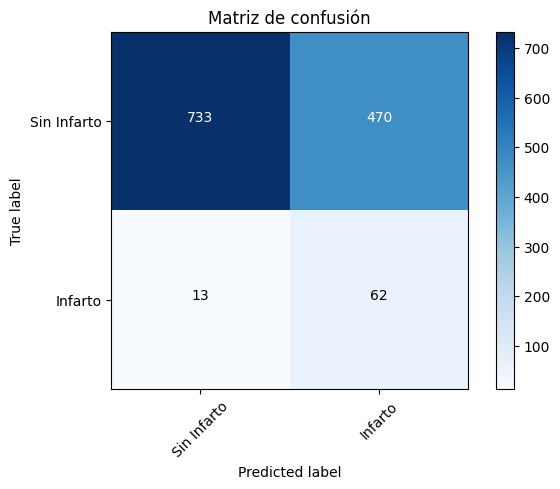

In [ ]:
# Damos el nombre a lo que queremos clasificar y llamamos a la función de matriz de confusión y evaluamos el modelo con el set de test
LABELS = ["Sin Infarto","Infarto"]
print(classification_report(YtestF, Yhat1))
cnf_matrix = confusion_matrix(YtestF, Yhat1)
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=LABELS,
                      title='Matriz de confusión')
plt.show()


#### 2.- Regresión Logística

En estadística, la regresión logística es un tipo de análisis de regresión utilizado para predecir el resultado de una variable categórica (una variable que puede adoptar un número limitado de categorías) en función de las variables independientes o predictoras. Es útil para modelar la probabilidad de un evento ocurriendo en función de otros factores. El análisis de regresión logística se enmarca en el conjunto de Modelos Lineales Generalizados (GLM por sus siglas en inglés) que usa como función de enlace la función logit. Las probabilidades que describen el posible resultado de un único ensayo se modelan como una función de variables explicativas, utilizando una función logística.

![](https://programmerclick.com/images/775/62478819e4f6f44e404de47566f85a17.png)

In [ ]:
# Buscamos el mejor modelo de acuerdo a todos los parámetros generados
params3 = {"max_iter": [100],
          "penalty": ['l1', 'l2'],
          "class_weight": ['None','balanced'],
          "solver" : ['newton-cg','lbfgs','liblinear','sag','saga'],
          "C": [1, 2, 3]}

model3 = LogisticRegression()
grid3 = GridSearchCV(estimator=model3, param_grid=params3,cv=skf, scoring=scoring_def)
grid3.fit(XtrainF, YtrainF)
print(grid3.best_score_)
print(grid3.best_params_)

# Se realiza la predicción del set de test con el mejor modelo
Yhat3 = grid3.best_estimator_.predict(XtestF)


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.10/dist-packages/

0.8341450216450217
{'C': 3, 'class_weight': 'balanced', 'max_iter': 100, 'penalty': 'l2', 'solver': 'saga'}


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning:


312 fits failed out of a total of 480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
240 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 1160, in fit
    self._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 600, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sk

              precision    recall  f1-score   support

           0       0.98      0.75      0.85      1203
           1       0.15      0.73      0.25        75

    accuracy                           0.75      1278
   macro avg       0.57      0.74      0.55      1278
weighted avg       0.93      0.75      0.81      1278

Matriz de confusión sin normalizar
[[900 303]
 [ 20  55]]


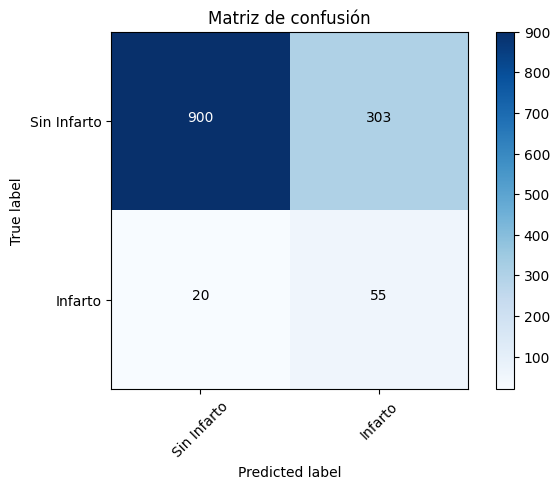

In [ ]:
# Damos el nombre a lo que queremos clasificar y llamamos a la función de matriz de confusión y evaluamos el modelo con el set de test
print(classification_report(YtestF, Yhat3))
cnf_matrix3 = confusion_matrix(YtestF, Yhat3)
plt.figure()
plot_confusion_matrix(cnf_matrix3, classes=LABELS,
                      title='Matriz de confusión')
plt.show()

#### 3.- Support Vector Machine

Una máquina de vectores de soporte (SVM) es un modelo de aprendizaje automático supervisado que utiliza algoritmos de clasificación para problemas de clasificación de dos grupos.

El objetivo del algoritmo de máquina de vectores de soporte es encontrar un hiperplano en un espacio N-dimensional (N - el número de características) que clasifica claramente los puntos de datos.

![](https://iartificial.net/wp-content/uploads/2019/04/Clasificacion-SVM-1024x582.png)

In [ ]:
# Buscamos el mejor modelo de acuerdo a todos los parámetros generados
params4 = {"max_iter": [100],
          "kernel": ['linear', 'poly', 'rbf', 'sigmoid'],
          "class_weight": ['None','balanced'],
          "gamma" : ['scale', 'auto'],
          "C": [1, 2, 3],
          "tol":[1e-5, 1e-6]}

model4 = svm.SVC()
grid4 = GridSearchCV(estimator=model4, param_grid=params4,cv=skf, scoring=scoring_def)
grid4.fit(XtrainF, YtrainF)
print(grid4.best_score_)
print(grid4.best_params_)

# Se realiza la predicción del set de test con el mejor modelo
Yhat4 = grid4.best_estimator_.predict(XtestF)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning:

Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning:

Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning:

Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning:

Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning:

Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.



0.9943181818181819
{'C': 1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': 100, 'tol': 1e-05}


/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning:

Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning:


384 fits failed out of a total of 768.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
384 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py", line 180, in fit
    self._validate_param

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1203
           1       0.06      1.00      0.11        75

    accuracy                           0.06      1278
   macro avg       0.03      0.50      0.06      1278
weighted avg       0.00      0.06      0.01      1278

Matriz de confusión sin normalizar
[[   0 1203]
 [   0   75]]


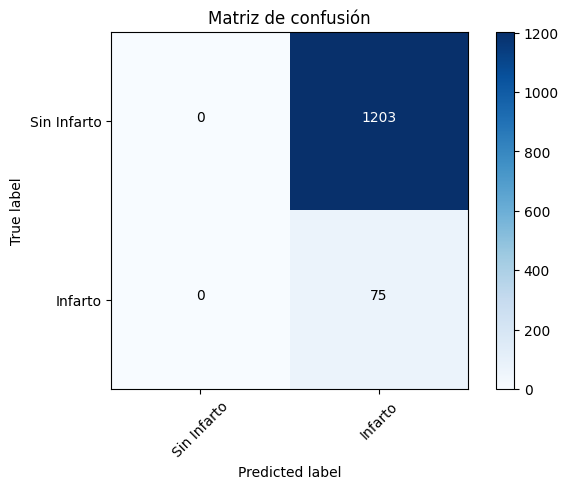

In [ ]:
# Damos el nombre a lo que queremos clasificar y llamamos a la función de matriz de confusión y evaluamos el modelo con el set de test
print(classification_report(YtestF, Yhat4))
cnf_matrix4 = confusion_matrix(YtestF, Yhat4)
plt.figure()
plot_confusion_matrix(cnf_matrix4, classes=LABELS,
                      title='Matriz de confusión')
plt.show()

#### 4.- Vecinos cercanos

La idea es realmente sencilla: el algoritmo clasifica cada dato nuevo en el grupo que corresponda, según tenga k vecinos más cerca de un grupo o de otro. Es decir, calcula la distancia del elemento nuevo a cada uno de los existentes, y ordena dichas distancias de menor a mayor para ir seleccionando el grupo al que pertenecer. Este grupo será, por tanto, el de mayor frecuencia con menores distancias.

El K-NN es un algoritmo de aprendizaje supervisado, es decir, que a partir de un juego de datos inicial su objetivo será el de clasificar correctamente todas las instancias nuevas. El juego de datos típico de este tipo de algoritmos está formado por varios atributos descriptivos y un solo atributo objetivo (también llamado clase).

![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR54tM0clp38B9THiQBD1C-cR4HJsWUe8oHL6lf4QDyqLT1iZ6s0uqmEboTsh29hCLQ7q0&usqp=CAU)

In [ ]:
# Buscamos el mejor modelo de acuerdo a todos los parámetros generados
params5 = {"n_neighbors": [2, 5, 10, 12],
          "algorithm": ['ball_tree', 'kd_tree', 'brute', 'auto'],
          "weights": ['uniform', 'distance'],
          "leaf_size" : [30, 40],
          "p": [1, 2]}

model5 = KNeighborsClassifier()
grid5 = GridSearchCV(estimator=model5, param_grid=params5,cv=skf, scoring=scoring_def)
grid5.fit(XtrainF, YtrainF)
print(grid5.best_score_)
print(grid5.best_params_)

# Se realiza la predicción del set de test con el mejor modelo
Yhat5 = grid5.best_estimator_.predict(XtestF)

0.09145021645021645
{'algorithm': 'ball_tree', 'leaf_size': 30, 'n_neighbors': 2, 'p': 2, 'weights': 'distance'}


              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1203
           1       0.14      0.11      0.12        75

    accuracy                           0.91      1278
   macro avg       0.54      0.53      0.54      1278
weighted avg       0.90      0.91      0.90      1278

Matriz de confusión sin normalizar
[[1152   51]
 [  67    8]]


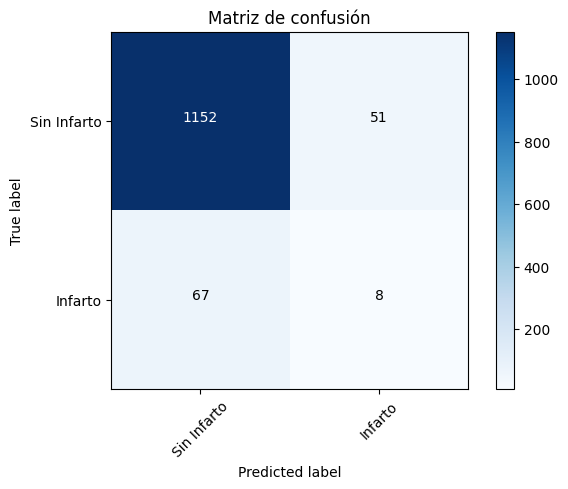

In [ ]:
# Damos el nombre a lo que queremos clasificar y llamamos a la función de matriz de confusión y evaluamos el modelo con el set de test
print(classification_report(YtestF, Yhat5))
cnf_matrix5 = confusion_matrix(YtestF, Yhat5)
plt.figure()
plot_confusion_matrix(cnf_matrix5, classes=LABELS,
                      title='Matriz de confusión')
plt.show()

# Modelos de ensamblaje, votación por mayoría y bagging

#### 1.- Bagging

En los algoritmos de conjunto, los métodos de empaquetamiento forman una clase de algoritmos que construyen varias instancias de un estimador de caja negra en subconjuntos aleatorios del conjunto de entrenamiento original y luego agregan sus predicciones individuales para formar una predicción final. Estos métodos se utilizan como una forma de reducir la varianza de un estimador base (por ejemplo, un árbol de decisión), introduciendo la aleatorización en su procedimiento de construcción y luego formando un conjunto a partir de ella. En muchos casos, los métodos de ensacado constituyen una forma muy sencilla de mejorar respecto a un único modelo, sin necesidad de adaptar el algoritmo de base subyacente. Dado que proporcionan una manera de reducir el ajuste excesivo, los métodos de ensacado funcionan mejor con modelos fuertes y complejos (por ejemplo, árboles de decisión completamente desarrollados), en contraste con los métodos de refuerzo que generalmente funcionan mejor con modelos débiles (por ejemplo, árboles de decisión poco profundos).

Los métodos de Bagging vienen en muchos tipos, pero la mayoría difieren entre sí por la forma en que dibujan subconjuntos aleatorios del conjunto de entrenamiento:

Cuando se dibujan subconjuntos aleatorios del conjunto de datos como subconjuntos aleatorios de las muestras, este algoritmo se conoce como Pasting.
Cuando las muestras se toman con reemplazo, entonces el método se conoce como Bagging.
Cuando los subconjuntos aleatorios del conjunto de datos se dibujan como subconjuntos aleatorios de las características, el método se conoce como Subespacios aleatorios.
Por último, cuando los estimadores de base se construyen sobre subconjuntos de muestras y características, el método se conoce como Parches aleatorios.

![](https://bookdown.org/content/2031/images/bootstraping.png)

In [ ]:
# Buscamos el mejor modelo de acuerdo a todos los parámetros generados
params6 = {"n_estimators":[100],
          "max_samples":[6, 8]}

model6 = BaggingClassifier(grid1.best_estimator_)
grid6 = GridSearchCV(estimator=model6, param_grid=params6,cv=skf, scoring=scoring_def)
grid6.fit(XtrainF, YtrainF)
print(grid6.best_score_)
print(grid6.best_params_)

# Se realiza la predicción del set de test con el mejor modelo
Yhat6 = grid6.best_estimator_.predict(XtestF)

0.0
{'max_samples': 6, 'n_estimators': 100}


              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1203
           1       0.00      0.00      0.00        75

    accuracy                           0.94      1278
   macro avg       0.47      0.50      0.48      1278
weighted avg       0.89      0.94      0.91      1278

Matriz de confusión sin normalizar
[[1203    0]
 [  75    0]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning:

Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



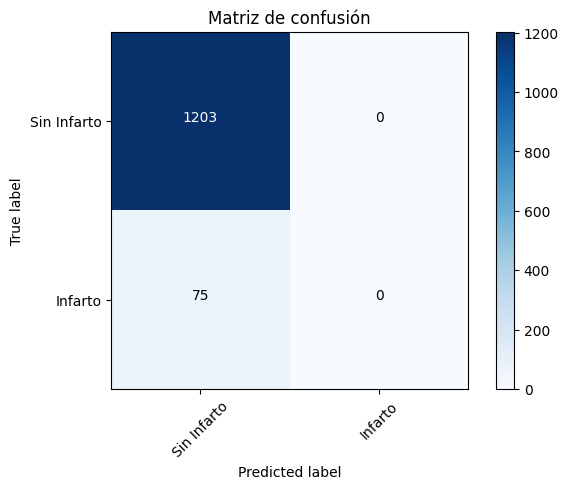

In [ ]:
# Damos el nombre a lo que queremos clasificar y llamamos a la función de matriz de confusión y evaluamos el modelo con el set de test
print(classification_report(YtestF, Yhat6))
cnf_matrix6 = confusion_matrix(YtestF, Yhat6)
plt.figure()
plot_confusion_matrix(cnf_matrix6, classes=LABELS,
                      title='Matriz de confusión')
plt.show()

#### 2.- Random Forest

En Random Forest se ejecutan varios algoritmos de árbol de decisiones en lugar de uno solo. Para clasificar un nuevo objeto basado en atributos, cada árbol de decisión da una clasificación y finalmente la decisión con mayor “votos” es la predicción del algoritmo.

![](https://iartificial.net/wp-content/uploads/2019/06/Random-Forest-Bagging.png)

In [ ]:
# Buscamos el mejor modelo de acuerdo a todos los parámetros generados
paramsRF = {"n_estimators": [100],
          "max_depth": [4, 6, 8, 10, 12],
          "class_weight": ['balanced_subsample','balanced'],
          "criterion" : ['gini','entropy'],
          "min_samples_split": [2, 4, 6],
          "max_features": ['auto', 'sqrt', 'log2']}

modelRF = RandomForestClassifier()
gridRF = GridSearchCV(estimator=modelRF, param_grid=paramsRF,cv=skf, scoring=scoring_def)
gridRF.fit(XtrainF, YtrainF)
print(gridRF.best_score_)
print(gridRF.best_params_)

# Se realiza la predicción del set de test con el mejor modelo
YhatRF = gridRF.best_estimator_.predict(XtestF)


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning:

`max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning:

`max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning:

`max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifi

0.8517316017316017
{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 4, 'max_features': 'auto', 'min_samples_split': 2, 'n_estimators': 100}


              precision    recall  f1-score   support

           0       0.98      0.71      0.83      1203
           1       0.15      0.80      0.25        75

    accuracy                           0.72      1278
   macro avg       0.57      0.76      0.54      1278
weighted avg       0.93      0.72      0.79      1278

Matriz de confusión sin normalizar
[[859 344]
 [ 15  60]]


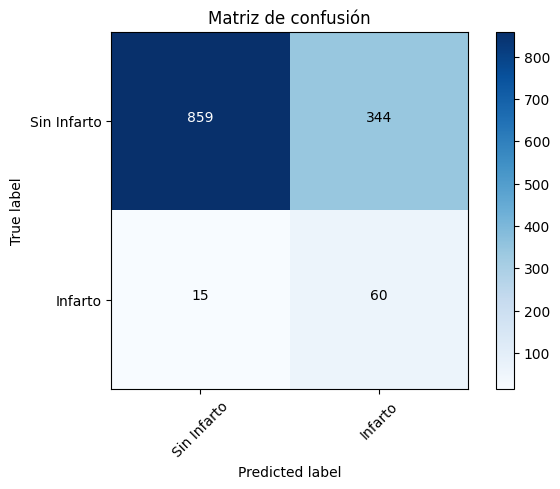

In [ ]:
# Damos el nombre a lo que queremos clasificar y llamamos a la función de matriz de confusión y evaluamos el modelo con el set de test
print(classification_report(YtestF, YhatRF))
cnf_matrix2 = confusion_matrix(YtestF, YhatRF)
plt.figure()
plot_confusion_matrix(cnf_matrix2, classes=LABELS,
                      title='Matriz de confusión')
plt.show()

# Modelos de ensamblaje por boosting y Stacking

#### 1.- Gradient-Boosted tree Classifier

Los clasificadores de aumento de gradiente son un grupo de algoritmos de aprendizaje automático que combinan muchos modelos de aprendizaje débiles para crear un modelo predictivo sólido. Los árboles de decisión generalmente se usan al aumentar el gradiente.

![](https://2.bp.blogspot.com/-Dx97g4KSWGw/Ww0Aa8RyGUI/AAAAAAAABnc/hdEpxgQ-XforLeICrdwYisCYNJN8KuLDQCLcBGAs/s400/gradient-boosting.png)

In [ ]:
# Buscamos el mejor modelo de acuerdo a todos los parámetros generados
params7 = {"n_estimators": [100],
          "loss": ['deviance', 'exponential'],
          "learning_rate" : [0.1, 0.01, 0.001],
          "max_features": ['auto', 'sqrt', 'log2'],
          "max_depth": [8, 10, 12],
          "min_samples_split": [2, 4, 6]
          }

model7 = GradientBoostingClassifier()
grid7 = GridSearchCV(estimator=model7, param_grid=params7,cv=skf, scoring=scoring_def)
grid7.fit(XtrainF, YtrainF)
print(grid7.best_score_)
print(grid7.best_params_)

# Se realiza la predicción del set de test con el mejor modelo
Yhat7 = grid7.best_estimator_.predict(XtestF)

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning:

`max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.

/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning:

`max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.

/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning:

`max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.

/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning:

`max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.

/usr/local/lib/python3.10/dist-packag

0.1093073593073593
{'learning_rate': 0.1, 'loss': 'exponential', 'max_depth': 12, 'max_features': 'auto', 'min_samples_split': 2, 'n_estimators': 100}


/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning:

`max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.

/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning:

`max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.

/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning:

`max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.

/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning:

`max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.



              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1203
           1       0.31      0.11      0.16        75

    accuracy                           0.93      1278
   macro avg       0.63      0.55      0.56      1278
weighted avg       0.91      0.93      0.92      1278

Matriz de confusión sin normalizar
[[1185   18]
 [  67    8]]


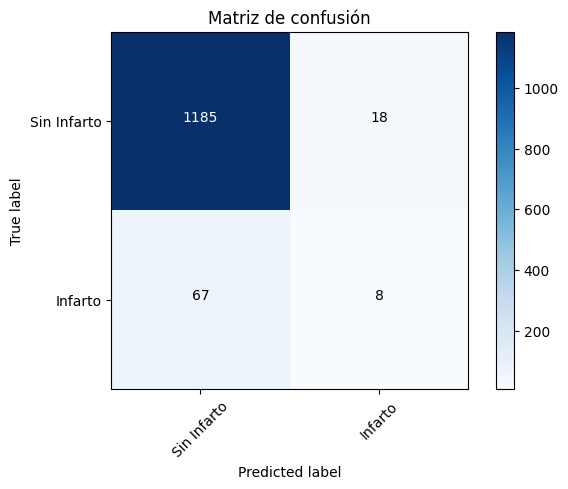

In [ ]:
# Damos el nombre a lo que queremos clasificar y llamamos a la función de matriz de confusión y evaluamos el modelo con el set de test
print(classification_report(YtestF, Yhat7))
cnf_matrix7 = confusion_matrix(YtestF, Yhat7)
plt.figure()
plot_confusion_matrix(cnf_matrix7, classes=LABELS,
                      title='Matriz de confusión')
plt.show()

#### 2.- ADA-Boost

AdaBoost es un algoritmo de impulso específico (también conocido como AdaBoost discreto) desarrollado para problemas de clasificación.
En cada iteración, AdaBoost identificará el punto de datos mal clasificado, aumentando así su peso (en cierto sentido, reduciendo el peso del punto correcto), de modo que el siguiente clasificador será más Presta atención para corregirlo.

![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRKIbQ5uXeWC1vq04hsNL0VNnWRZotwcYVur_W1Pzr8NlRKMnXGTmOrNhakHlXHTHlemU4&usqp=CAU)

In [ ]:
# Buscamos el mejor modelo de acuerdo a todos los parámetros generados
params8 = {"learning_rate" : [0.1, 0.01, 0.001],
          "n_estimators": [100],
          "algorithm" : ['SAMME', 'SAMME.R']
          }


model8 = AdaBoostClassifier(grid1.best_estimator_)
grid8 = GridSearchCV(estimator=model8, param_grid=params8,cv=skf, scoring=scoring_def)
grid8.fit(XtrainF, YtrainF)
print(grid8.best_score_)
print(grid8.best_params_)

# Se realiza la predicción del set de test con el mejor modelo
Yhat8 = grid8.best_estimator_.predict(XtestF)

0.7713744588744589
{'algorithm': 'SAMME', 'learning_rate': 0.01, 'n_estimators': 100}


              precision    recall  f1-score   support

           0       0.98      0.75      0.85      1203
           1       0.15      0.71      0.25        75

    accuracy                           0.75      1278
   macro avg       0.56      0.73      0.55      1278
weighted avg       0.93      0.75      0.82      1278

Matriz de confusión sin normalizar
[[906 297]
 [ 22  53]]


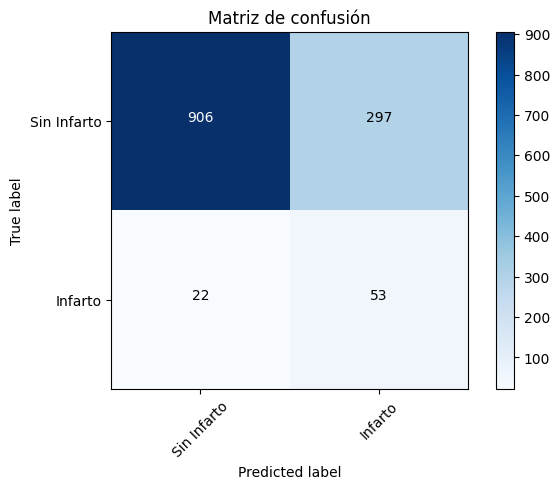

In [ ]:
# Damos el nombre a lo que queremos clasificar y llamamos a la función de matriz de confusión y evaluamos el modelo con el set de test
print(classification_report(YtestF, Yhat8))
cnf_matrix8 = confusion_matrix(YtestF, Yhat8)
plt.figure()
plot_confusion_matrix(cnf_matrix8, classes=LABELS,
                      title='Matriz de confusión')
plt.show()

#### 3.- Stacking

El aprendizaje integrado se divide principalmente en métodos de ensacado, refuerzo y apilamiento. El proceso de apilamiento se muestra en la siguiente figura. Primero, m clasificadores base (o regresores) se entrenan en el conjunto de entrenamiento. Los resultados de predicción (que pueden ser etiquetas o probabilidades) generados por estos m clasificadores se ingresan como nuevas característicasMeta-ClassifierPara entrenar Meta-Classifier, generalmente Meta-Classifier usará LogisticRegression. En la predicción, cada muestra pasa primero todos los m clasificadores para obtener una nueva característica (etiqueta o probabilidad), y la nueva característica se ingresa al Metaclasificador para obtener el resultado final de la predicción.

![](https://ichi.pro/assets/images/max/724/1*3LgG3geyPppu52SwZ4b5kQ.png)

In [ ]:
# Buscamos el mejor modelo de acuerdo a todos los parámetros generados
params9 = {"stack_method": ['auto', 'predict_proba', 'decision_function', 'predict']}

estimators = [
        ('dt', grid1.best_estimator_),
        ('rf', grid2.best_estimator_),
        ('sv', grid4.best_estimator_),
        ('kn', grid5.best_estimator_)
    ]
model9 = StackingClassifier(
        estimators=estimators, final_estimator=grid3.best_estimator_
    )
grid9 = GridSearchCV(estimator=model9, param_grid=params9,cv=skf, scoring=scoring_def)
grid9.fit(XtrainF, YtrainF)
print(grid9.best_score_)
print(grid9.best_params_)

# Se realiza la predicción del set de test con el mejor modelo
Yhat9 = grid9.best_estimator_.predict(XtestF)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning:

Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning:

Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning:

Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning:

Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning:

Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.



0.8460497835497836
{'stack_method': 'auto'}


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



In [ ]:
# Damos el nombre a lo que queremos clasificar y llamamos a la función de matriz de confusión y evaluamos el modelo con el set de test
print(classification_report(YtestF, Yhat9))
cnf_matrix9 = confusion_matrix(YtestF, Yhat9)
plt.figure()
plot_confusion_matrix(cnf_matrix9, classes=LABELS,
                      title='Matriz de confusión')
plt.show()

# En conclusión

El flujo usual a la hora de entrenar un clasificador es el siguiente:

1. Tener datos. Verificar la fuente de los datos, la existencia de sesgos (sesgo de selección, sesgos sociodemográficos, etc.).
2. Realizar exploración y limpieza de datos en ambos sets, de manera independiente.
3. Separar datos en set de entrenamiento y prueba.
4. Elegir clasificadores apropiados para el dominio del problema.
5. Determinar métricas de entrenamiento usando cross-validation, si es posible (más de esto en el lab de mañana).
6. Evaluar el set de pruebas.

# Referencias

1. Documentación de scikit-learn. http://scikit-learn.org/stable/index.html
2. Precision y Recall. https://en.wikipedia.org/wiki/Precision_and_recall
3. Curso Machine Learning en la nube

###### ***Curso: Machine Learning en la nube***
###### ***Autor: Marcelo Miranda Williams***
###### ***Editado durante cursada: Analía Elizabeth Gomory***